### Table of Contents

* [Goals](#goals)
* [Data](#Data)
    * [Import and Inspect Data](#section1_1)
    * [Data Information](#section1_2)
* [Data Cleaning](#cleaning)
    * [Adding an Age Column](#section2_1)
    * [Checking the Education Variable](#section2_2)
* [Exploratory Data Analysis](#EDA)
    * [Big Picture](#section3_1)
    * [Purchasing Behavior by Income](#section3_2)
    * [More Purchasing Behavior by Income](#section3_3)
    * [Purchasing Behavior by Education and Income](#section3_4)
    * [Purchasing Behavior by Age](#section3_5)
* [Conclusion](#conclusion)
    

In [2]:
# import modules
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import re

### Import and inspect data <a class="anchor" id="loading"></a>

In [3]:
# import data
market_data = pd.read_csv("market_data.csv")
# see all columns

pd.set_option('display.max_columns', None)

# check the first few rows of the data
market_data.head()

,id,YearBirth,Education,MaritalStatus,Income,Kidhome,Teenhome,DtCustomer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,SP


In [4]:
# check the columns of the data
market_data.columns

Index(['id', 'YearBirth', 'Education', 'MaritalStatus', 'Income', 'Kidhome',
       'Teenhome', 'DtCustomer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProducts', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='str')

In [5]:
# check the data types and null values
market_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id                   2240 non-null   int64
 1   YearBirth            2240 non-null   int64
 2   Education            2240 non-null   str  
 3   MaritalStatus        2240 non-null   str  
 4   Income               2216 non-null   str  
 5   Kidhome              2240 non-null   int64
 6   Teenhome             2240 non-null   int64
 7   DtCustomer           2240 non-null   str  
 8   Recency              2240 non-null   int64
 9   MntWines             2240 non-null   int64
 10  MntFruits            2240 non-null   int64
 11  MntMeatProducts      2240 non-null   int64
 12  MntFishProducts      2240 non-null   int64
 13  MntSweetProducts     2240 non-null   int64
 14  MntGoldProducts      2240 non-null   int64
 15  NumDealsPurchases    2240 non-null   int64
 16  NumWebPurchases      2240 non-null 

In [6]:
# check for missing values
market_data.isnull().sum()

id                      0
YearBirth               0
Education               0
MaritalStatus           0
Income                 24
Kidhome                 0
Teenhome                0
DtCustomer              0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProducts         0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [7]:
# display summary statistics for numerical columns
market_data.describe()

,id,YearBirth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Data Overview <a class="anchor" id="section1_2"></a>


* Dataset has 28 columns and 2240 rows.
* Most variales have integers as values.
* The ` income` column has missing data, values that are not integers or floats, and an extra space in the column name, so some cleaning will be necessary for this column prior to conducting EDA. 
* The column names could be renamed for more consistency.
* Some basic summary statistics on each of the numerical variables.

#### Data Cleaning <a class="anchor" id="cleaning"></a>

As mentioned before, the `Income` column could use some cleaning. The column names overall could also be renamed for more consistency. To do this, the following is done:
* Put all columns in [snake case format](https://www.ssc.wisc.edu/sscc/pubs/DWE/book/4-2-naming-variables.html) using regex and list comprehension
* Change `Income` values to floats
* Set the values as floats

The `Income` distribution is then looked at using boxplots. Since there is one large outlier, it is removed from the `market_data`. Next, the missing values are replaced with the mean income using the `.mean()` method.

`Income` is one of the main variables that will be explored in the analysis, so it is essential that it is tidy and ready for exploration

In [8]:
# Clean Income Column

# remove dollar sign and convert to float
market_data['Income'] = market_data['Income'].replace('[\\$,]', '', regex=True).astype(float)

# summary stats for income column
market_data['Income'].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

In [9]:
# convert columns names into snake case format
market_data.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', x).lower() for x in market_data.columns]

# check column names after cleaning
market_data.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mnt_wines', 'mnt_fruits',
       'mnt_meat_products', 'mnt_fish_products', 'mnt_sweet_products',
       'mnt_gold_products', 'num_deals_purchases', 'num_web_purchases',
       'num_catalog_purchases', 'num_store_purchases', 'num_web_visits_month',
       'accepted_cmp3', 'accepted_cmp4', 'accepted_cmp5', 'accepted_cmp1',
       'accepted_cmp2', 'response', 'complain', 'country'],
      dtype='str')

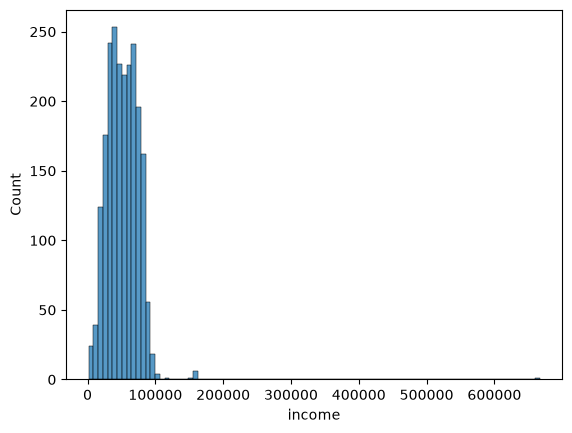

In [10]:
# visualize the distribution of the income column
plt.figure()
sns.histplot(market_data["income"])
plt.show()

The distribution of the income data is right skewed, indicating the prsence of outliers. The outliers will be removed.

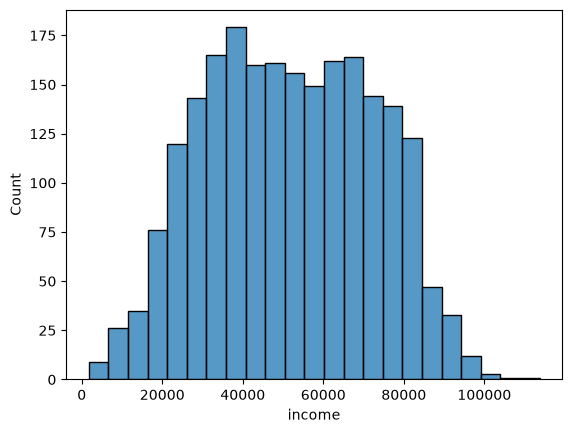

In [11]:
# remove incomes below 300000
market_data = market_data[market_data['income'] < 150000]

plt.figure()
sns.histplot(market_data["income"])
plt.show()

After the removal of outliers, the distribution of the `income` variable is now a normal distribution.

In [12]:
# replace missing values with the mean income
market_data['income'] = market_data['income'].fillna(market_data['income'].mean())



#### Create Age Column

The `market_data` DataFrame contains a `year_birth` column; however, a column with the age of each customer may be easier for analysis. Because of this, the following is done:

* Create an `age` column by subracting each value of `year_birth` from 2020 (the year the dataset was created). 
* Check for outliers in `age` that could affect the analysis are removed. 

In [13]:
# create a new column for age using the year_birth column
market_data['age'] = 2020 - market_data['year_birth']

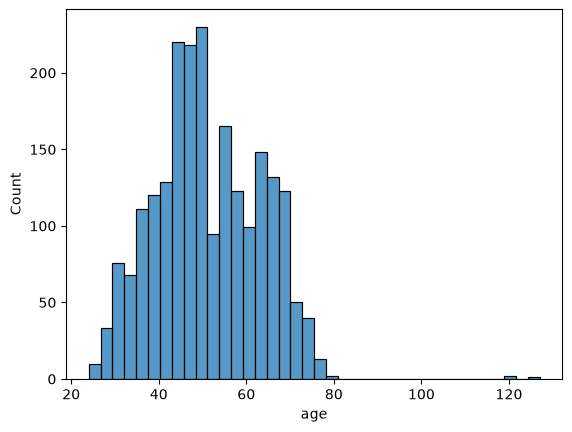

In [15]:
# visualize the distribution of the age column
plt.figure()
sns.histplot(market_data["age"])
plt.show()

In [16]:
# display summary statistics for the age column
market_data["age"].describe()

count    2208.000000
mean       51.192935
std        11.991913
min        24.000000
25%        43.000000
50%        50.000000
75%        61.000000
max       127.000000
Name: age, dtype: float64

In [17]:
# remove outliers in the age column (age > 100)
market_data = market_data[market_data["age"] < 100]

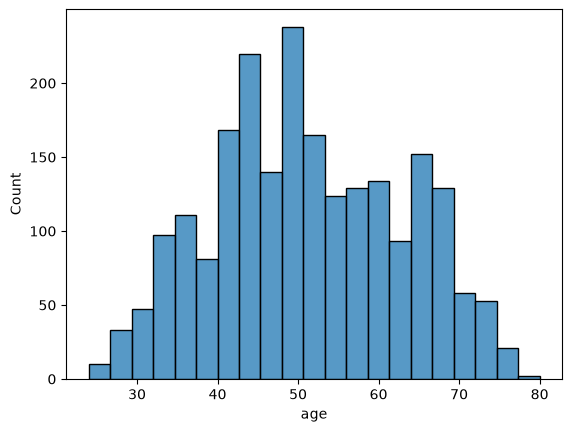

In [ ]:
# visualize the distribution of the age column after removing outliers
plt.figure()
sns.histplot(market_data["age"])
plt.show()

In [19]:
# display summary statistics for the age column after removing outliers
market_data["age"].describe()

count    2205.000000
mean       51.095692
std        11.705801
min        24.000000
25%        43.000000
50%        50.000000
75%        61.000000
max        80.000000
Name: age, dtype: float64

After removing the major outliers the `age` distribution is symmetric and ready for analysis.

#### Check the Education Variable 

The education variable will be a focus of analysis, so boxplots are used check if cleaning neccessary before EDA. 

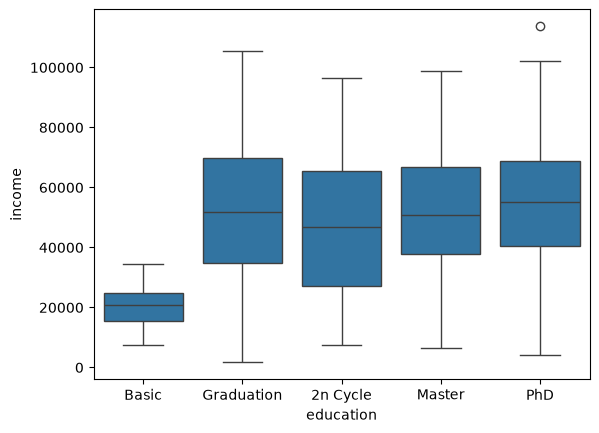

In [21]:
# visualize the distribution of the income column by education level
plt.figure()
sns.boxplot(x = market_data["education"], y=market_data["income"], 
            order=["Basic", "Graduation", "2n Cycle", "Master", "PhD"])
plt.show()

There boxplots suggest there are no issues; therefore, the data is left intact.

### Exploratory Data Analysis (EDA)

The following independent variables will be focused on in the EDA:
* `income`
* `education`
* `age`

Objective: determine how the above independent variables associate with the following dependent variables:
* `mnt_wines`
* `mnt_fruits`
* `mnt_meat_products`
* `mnt_fish_products`
* `mnt_sweet_products`  
* `mnt_gold_products`  
* `num_deals_purchases`
* `num_web_purchases`  
* `num_catalog_purchases`  
* `num_store_purchases`

Business Question:
* How does a shopper's income, education level, and/or age relate to their purchasing behavior? 

#### Visualize distribution of all variables in dataset

In order to observe the dataset as a whole, `DataFrame.hist()` is used.. It gives a full view of all numerical variables in the distribution. Most of the amount bought and number purchased variables are skewed right and have similar distributions.



/var/folders/ql/j_hbzljj3k12s8z32lc2jzyw0000gn/T/ipykernel_56899/3847976400.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  market_data.hist(ax = ax)


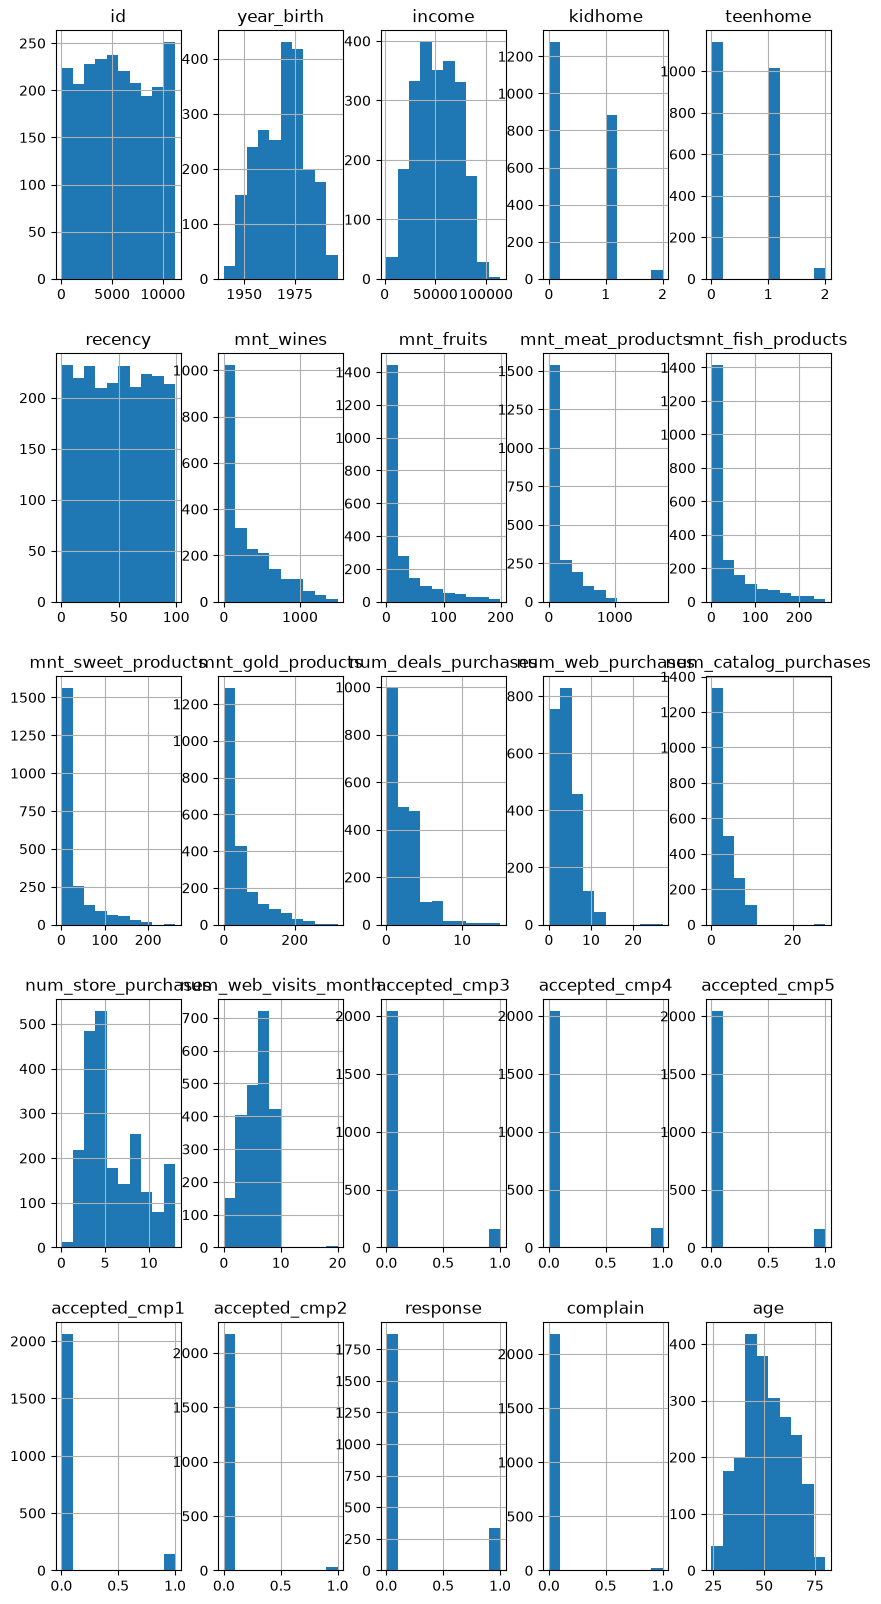

In [27]:
fig = plt.figure(figsize = (10,20))
ax = fig.gca()
market_data.hist(ax = ax)
plt.show()

This overview shows that the purchase behavior columns are all skewed to the right.

### Determine correlations between numerical variables

In [ ]:
# first, select only the numerical columns
market_data_numerical = market_data.select_dtypes(include=[np.number])
market_data_numerical.info()

<class 'pandas.DataFrame'>
Index: 2205 entries, 0 to 2239
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2205 non-null   int64  
 1   year_birth             2205 non-null   int64  
 2   income                 2205 non-null   float64
 3   kidhome                2205 non-null   int64  
 4   teenhome               2205 non-null   int64  
 5   recency                2205 non-null   int64  
 6   mnt_wines              2205 non-null   int64  
 7   mnt_fruits             2205 non-null   int64  
 8   mnt_meat_products      2205 non-null   int64  
 9   mnt_fish_products      2205 non-null   int64  
 10  mnt_sweet_products     2205 non-null   int64  
 11  mnt_gold_products      2205 non-null   int64  
 12  num_deals_purchases    2205 non-null   int64  
 13  num_web_purchases      2205 non-null   int64  
 14  num_catalog_purchases  2205 non-null   int64  
 15  num_store_purchases 

In [31]:
# display the correlation matrix
market_data_numerical.corr()

,id,year_birth,income,kidhome,teenhome,recency,mnt_wines,mnt_fruits,mnt_meat_products,mnt_fish_products,mnt_sweet_products,mnt_gold_products,num_deals_purchases,num_web_purchases,num_catalog_purchases,num_store_purchases,num_web_visits_month,accepted_cmp3,accepted_cmp4,accepted_cmp5,accepted_cmp1,accepted_cmp2,response,complain,age
id,1.000000,0.007344,0.001633,0.002030,-0.003292,-0.046991,-0.018822,0.010178,-0.001817,-0.022333,-0.004428,-0.008056,-0.040591,-0.017433,0.002944,-0.011595,-0.008582,-0.035753,-0.023757,-0.004473,-0.018042,-0.014934,-0.021187,0.031882,-0.007344
year_birth,0.007344,1.000000,-0.212625,0.238083,-0.362919,-0.014228,-0.164438,-0.013149,-0.041540,-0.040855,-0.021075,-0.059295,-0.072005,-0.161839,-0.140724,-0.138614,0.122713,0.061405,-0.069903,0.019275,-0.011747,-0.007737,0.021305,-0.004531,-1.000000
income,0.001633,-0.212625,1.000000,-0.531699,0.042483,0.006716,0.730495,0.537920,0.702500,0.551758,0.555601,0.417653,-0.132427,0.503184,0.710057,0.687206,-0.648306,-0.011181,0.233267,0.416386,0.345242,0.110210,0.174902,-0.027488,0.212625
kidhome,0.002030,0.238083,-0.531699,1.000000,-0.040207,0.011829,-0.499288,-0.374388,-0.445665,-0.389895,-0.379101,-0.356550,0.226434,-0.375590,-0.519813,-0.506543,0.448497,0.015897,-0.162597,-0.205124,-0.174741,-0.082124,-0.078409,0.037025,-0.238083
teenhome,-0.003292,-0.362919,0.042483,-0.040207,1.000000,0.013881,0.002783,-0.176925,-0.267177,-0.206371,-0.164246,-0.019619,0.394341,0.161229,-0.114019,0.047321,0.129365,-0.043223,0.037860,-0.190760,-0.145748,-0.015805,-0.155196,0.007633,0.362919
recency,-0.046991,-0.014228,0.006716,0.011829,0.013881,1.000000,0.016470,-0.004909,0.026138,0.001177,0.025535,0.018558,0.000479,-0.005104,0.029750,0.000462,-0.017906,-0.032327,0.017658,0.000334,-0.021097,-0.001390,-0.200413,0.005758,0.014228
mnt_wines,-0.018822,-0.164438,0.730495,-0.499288,0.002783,0.016470,1.000000,0.384947,0.593119,0.395967,0.388613,0.390194,0.011858,0.552342,0.673234,0.639373,-0.329395,0.060700,0.373063,0.472729,0.351346,0.206231,0.245559,-0.036709,0.164438
mnt_fruits,0.010178,-0.013149,0.537920,-0.374388,-0.176925,-0.004909,0.384947,1.000000,0.568100,0.592556,0.570986,0.392596,-0.136350,0.300813,0.513686,0.459056,-0.424463,0.014131,0.006078,0.208615,0.192061,-0.010147,0.122331,-0.003135,0.013149
mnt_meat_products,-0.001817,-0.041540,0.702500,-0.445665,-0.267177,0.026138,0.593119,0.568100,1.000000,0.595673,0.556511,0.375581,-0.165522,0.329453,0.714382,0.517245,-0.543387,0.021224,0.096798,0.389276,0.325306,0.045842,0.248821,-0.020921,0.041540
mnt_fish_products,-0.022333,-0.040855,0.551758,-0.389895,-0.206371,0.001177,0.395967,0.592556,0.595673,1.000000,0.582974,0.425420,-0.145030,0.297776,0.563174,0.456896,-0.453353,-0.000832,0.015513,0.194387,0.261389,0.002093,0.107405,-0.019299,0.040855


The heat matrix shows that `income` has the strongest association with numerous variables. Interestingly, it showed that `age` may not be a huge factor overall. This is something to look into it a bit more in the analysis.

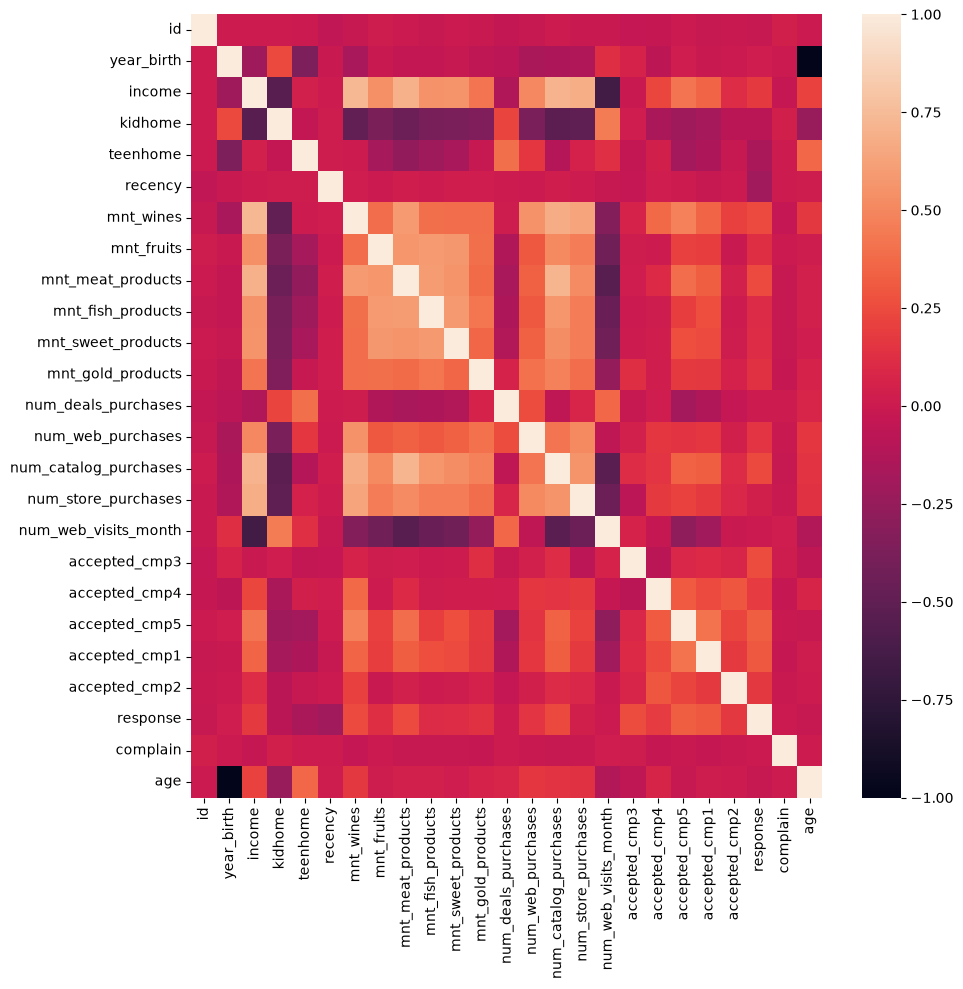

In [ ]:
# visualize heat matrix to show correlation across all numerical variables
plt.figure(figsize=(10,10))
sns.heatmap(data=market_data_numerical.corr(),annot=False)
plt.tight_layout()
plt.show()

#### Purchasing Behavior by Income <a class="anchor" id="section3_2"></a>

Now it's time to start looking into the big question. A `for` loop is used to see the relationship bewteen `income` and each `num_{type}_purchases` variable. The `hue` parameter with the `education` variable is used to see if there are any patterns that can be deciphered between `education` and `num_{type}_purchases`. 

First scatterplots are used and then regression plots are used for this analysis.

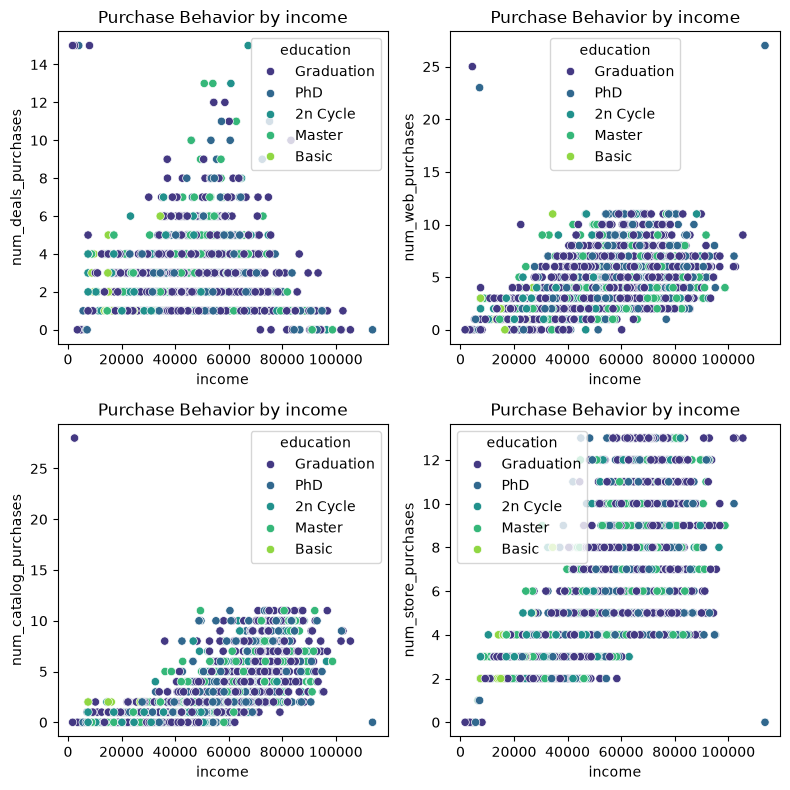

In [33]:
# num purchases columns list
num_purchases_cols = ["num_deals_purchases", "num_web_purchases", "num_catalog_purchases", "num_store_purchases"]
# keeps count of plot for subplots
plot = 0
fig = plt.figure(figsize=(8,8))
# loop through number of columns to plot
for i in range(len(num_purchases_cols)):
    plot += 1
    # subplot to create grid of plots
    ax = plt.subplot(2, 2, plot)
    # scatterplot of purchase type vs income with education
    sns.scatterplot(x=market_data["income"], y= market_data[num_purchases_cols[i]], 
                    hue=market_data["education"], palette="viridis")
    plt.title("Purchase Behavior by income")

plt.tight_layout()
plt.show()

There is a fairly strong, positive linear relationship between `income` and the following three variables:
* `num_catalog_purchases`
* `num_store_purchases`
* `num_web_purchases`

Between `income` and `NumDealsPurchaes`, however, there is no obvious relationship. It appears there might be a weak, negative linear relationship but it is not strong enough to be confident. It is also difficult to decipher any patterns associated with `education` in the plots, so further analysis will be done on this variable.

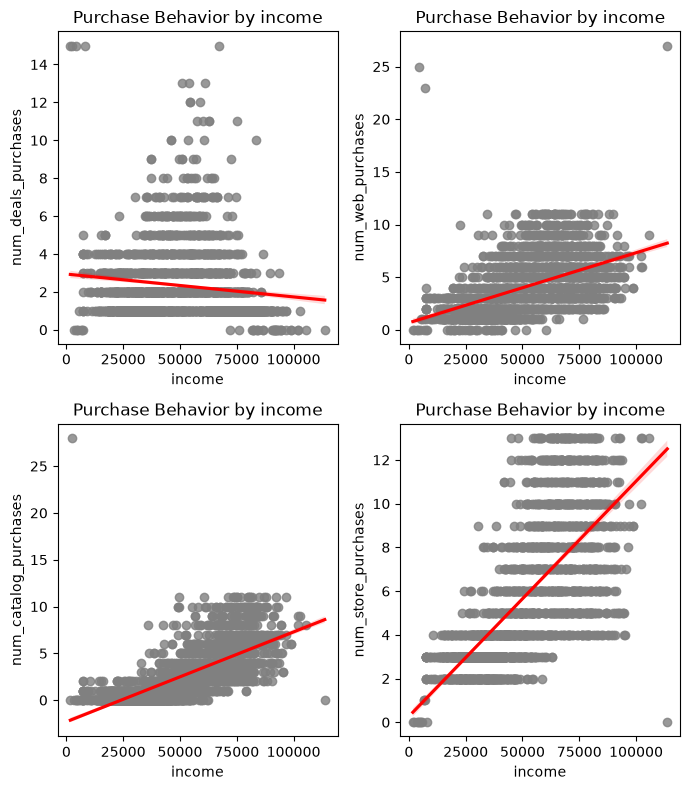

In [39]:
# num purchases columns list
num_purchases_cols = ["num_deals_purchases", "num_web_purchases", "num_catalog_purchases", "num_store_purchases"]
# keeps count of plot for subplots
fig = plt.figure(figsize=(7,8))
plot = 0
# loop through number of columns to plot
for i in range(len(num_purchases_cols)):
    plot += 1
    # set up subplots
    ax = plt.subplot(2, 2, plot)
    # regression plot of purchases vs. income
    sns.regplot(x=market_data["income"], y= market_data[num_purchases_cols[i]], 
                scatter_kws={"color": "gray"}, line_kws={"color": "red"})
    plt.title("Purchase Behavior by income")
plt.tight_layout()
plt.show()

To get a better look at the linear relationships, `.regplot()` was used. `num_catalog_purchases` and `num_store_purchases` have the strongest positive, linear relationship with `income`. 

These plots also show that `income` and `num_deals_purchases` have a linear, negative relationship; however, it is still too weak to be conclusive.

For some further analysis, a new column in the DataFrame called `total_purchases` is added to the `market_data` DataFrame. It is the sum of all `num_{type}_purchases` variables. The same analysis with `.scatterplot()` and `.regplot()` plot methods is done on this new column.

In [36]:
# add new total_purchases column to market_data
market_data["total_purchases"] = market_data["num_deals_purchases"]+market_data["num_catalog_purchases"] + market_data["num_web_purchases"] + market_data["num_store_purchases"]

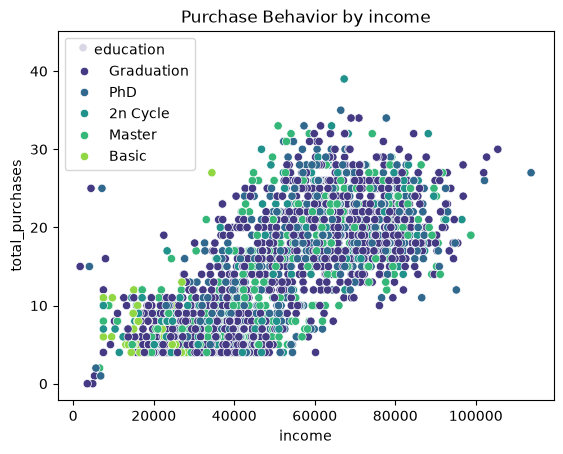

In [37]:
plt.figure()
# scatterplot of total_purchases vs. income
sns.scatterplot(y=market_data["total_purchases"], x=market_data["income"], 
                hue=market_data['education'], palette="viridis")
plt.title("Purchase Behavior by income")
plt.show()

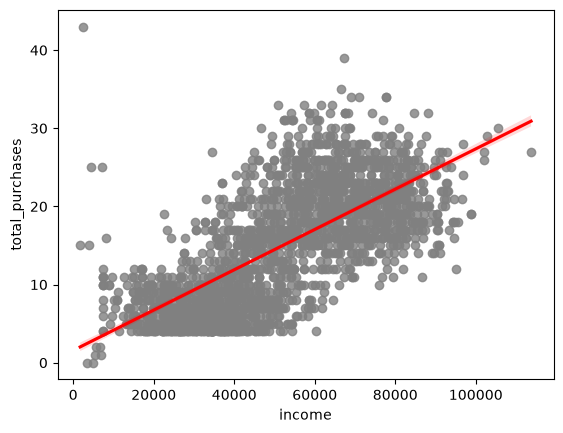

In [38]:
plt.figure()
# regression plot of total_purchases vs income
sns.regplot(y=market_data["total_purchases"], x=market_data["income"], 
            scatter_kws={"color": "gray"}, line_kws={"color": "red"})
plt.show()

The overall relationship between `income` and `total_purchases` is strong and linear. Unfortunately, it is still hard to decipher any relationship with the `education` and `total_purchases` as the points are scattered randomly across the plot.

#### More Purchasing Behavior by Income <a class="anchor" id="section3_3"></a>

The following analysis is very similar as before. However, instead of looking at the relationship between `income` and `num_{type}_purchases`, this analysis will be looking at the relationship between `income` and `mnt_{type}_products`. The steps for this analysis will essentially be the same.

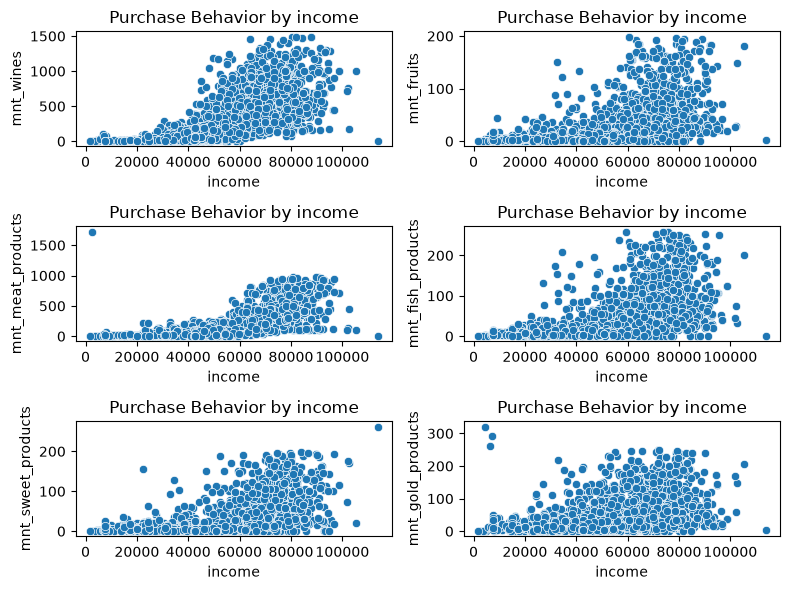

In [40]:
# amounts of items list
amounts_list = ["mnt_wines", "mnt_fruits", "mnt_meat_products", "mnt_fish_products", "mnt_sweet_products", "mnt_gold_products"]
plot = 0
fig = plt.figure(figsize=(8,6))
# for loop to go through length of amounts list
for i in range(len(amounts_list)):
    plot += 1
    # set up subplots
    ax = plt.subplot(3, 2, plot)
    # scatterplot of amount of items bought vs. income
    sns.scatterplot(y= market_data[amounts_list[i]], x=market_data["income"])
    plt.title("Purchase Behavior by income")
plt.tight_layout()
plt.show()

These plots all show a positive relationship between `income` and each `mnt_{type}_products` variable. However, there is not enough visual evidence to see that it is linear. For further analysis, The *log* scale of the the `income` variable and the `mnt_{type}_products` variables are plotted.

/Users/eliess/anaconda3/envs/datascience/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/eliess/anaconda3/envs/datascience/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/eliess/anaconda3/envs/datascience/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/eliess/anaconda3/envs/datascience/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/eliess/anaconda3/envs/datascience/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inp

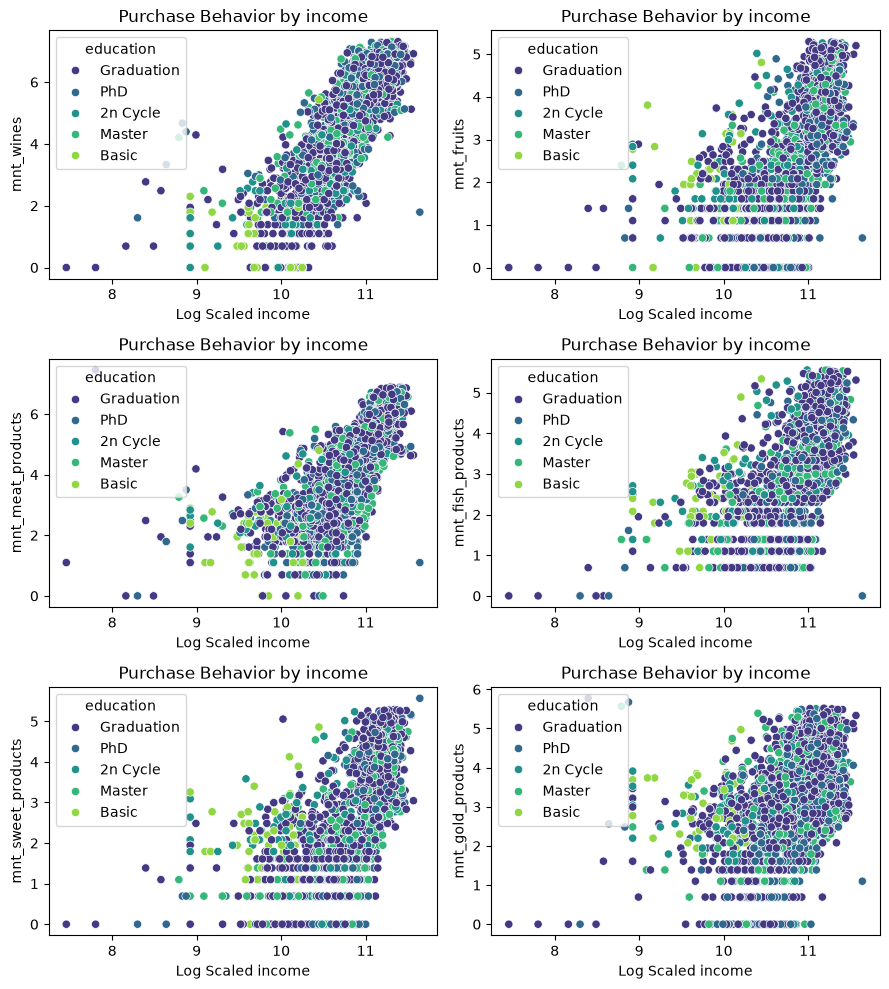

In [41]:
amounts_list = ["mnt_wines", "mnt_fruits", "mnt_meat_products", "mnt_fish_products", "mnt_sweet_products", "mnt_gold_products"]
axes = [None for column in amounts_list]
plot = 0
fig = plt.figure(figsize=(9,10))
for i in range(len(amounts_list)):
    plot += 1
    ax = plt.subplot(3, 2, plot)
    sns.scatterplot(y=np.log(market_data[amounts_list[i]]), x=np.log(market_data["income"]), 
                    hue=market_data["education"], palette="viridis")
    ax.set_xlabel("Log Scaled income")
    plt.title("Purchase Behavior by income")
plt.tight_layout()
plt.show()

With the *log* scaled variables, it is easy to see there is an fairly strong linear, positive relationship between the variables across the board. It is still hard to see how education plays a role, however.

#### Purchasing Behavior by Education and Income <a class="anchor" id="section3_4"></a>

A seaborn method called `.FacetGrid()` is used to see how education effects purchasing behavior along with `income`. It gives a much clearer picture than the `hue` parameter in previous plots. In this analysis, a loop and a dynamic Python variable are used to plot six sets of `.FacetGrid()` plots.

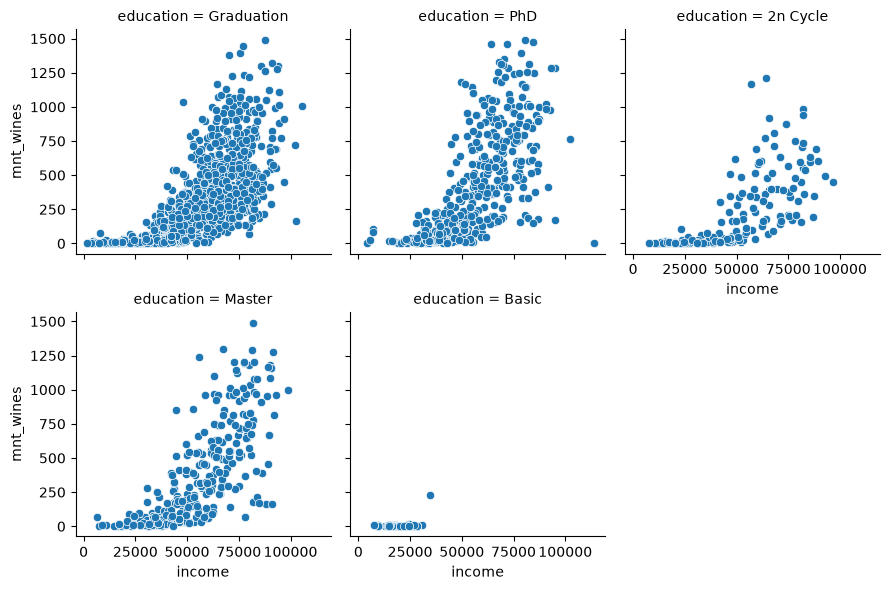

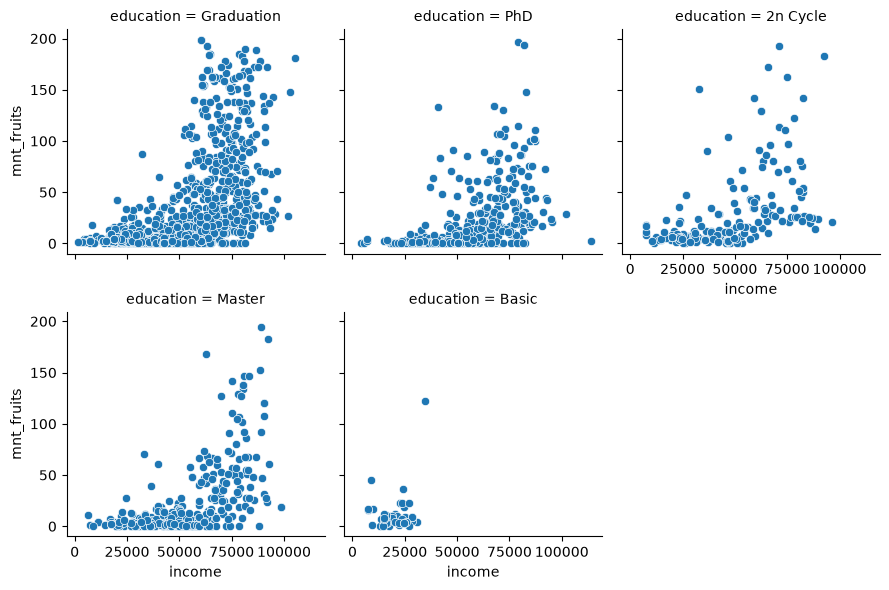

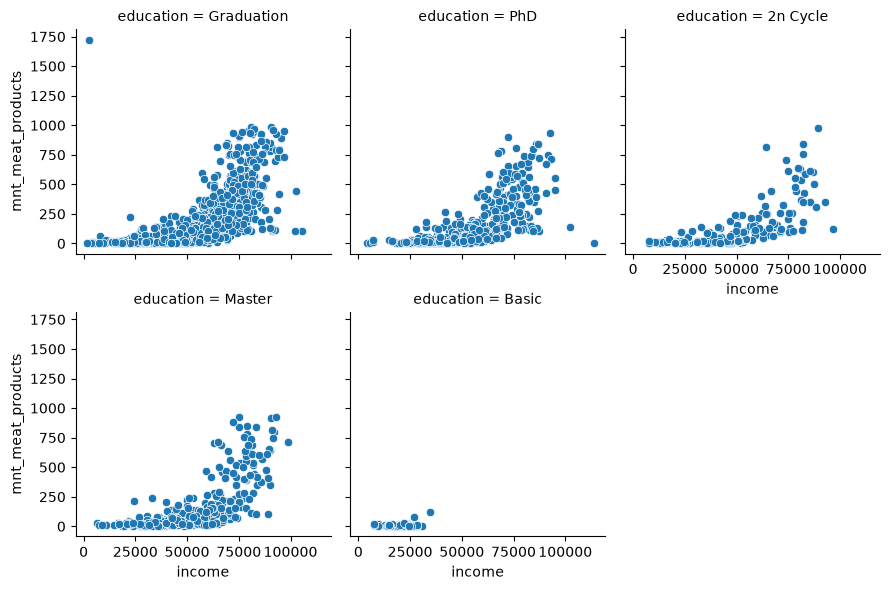

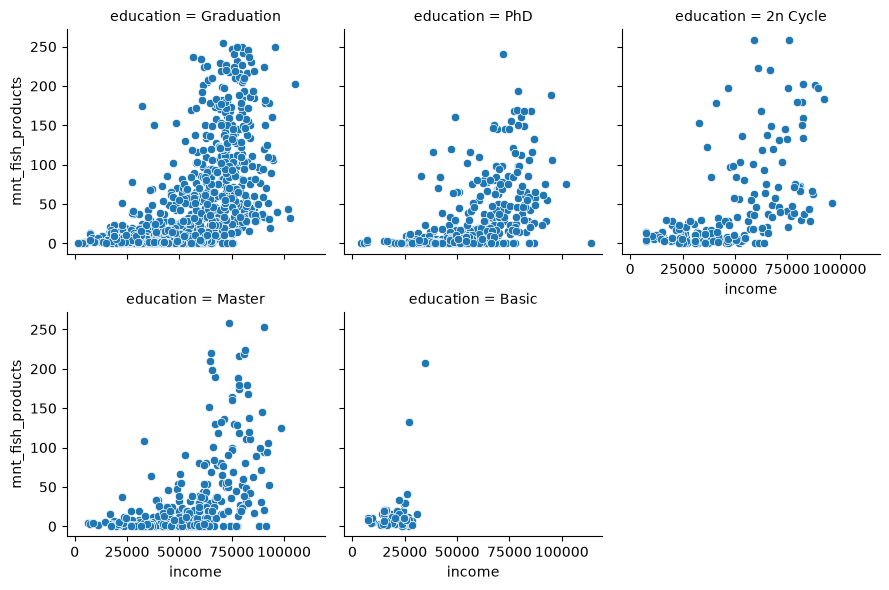

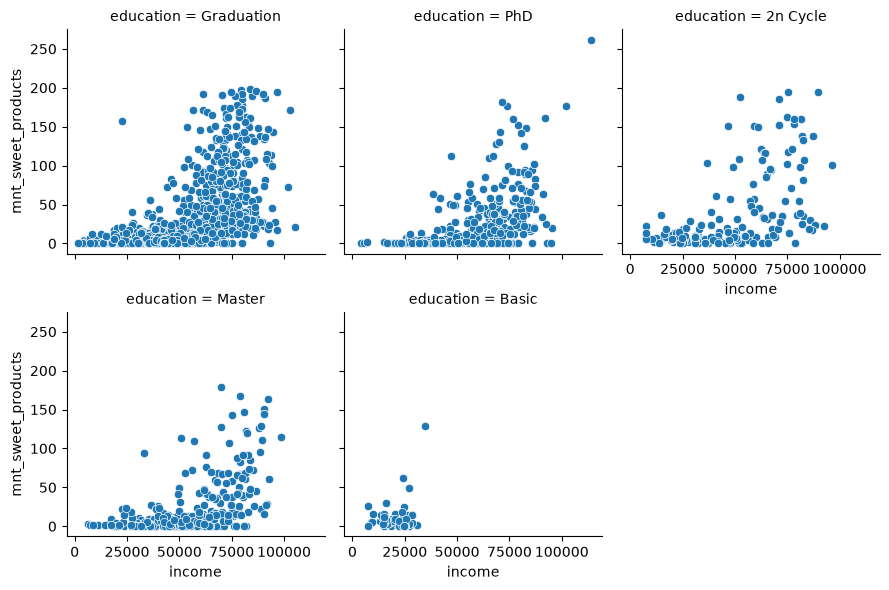

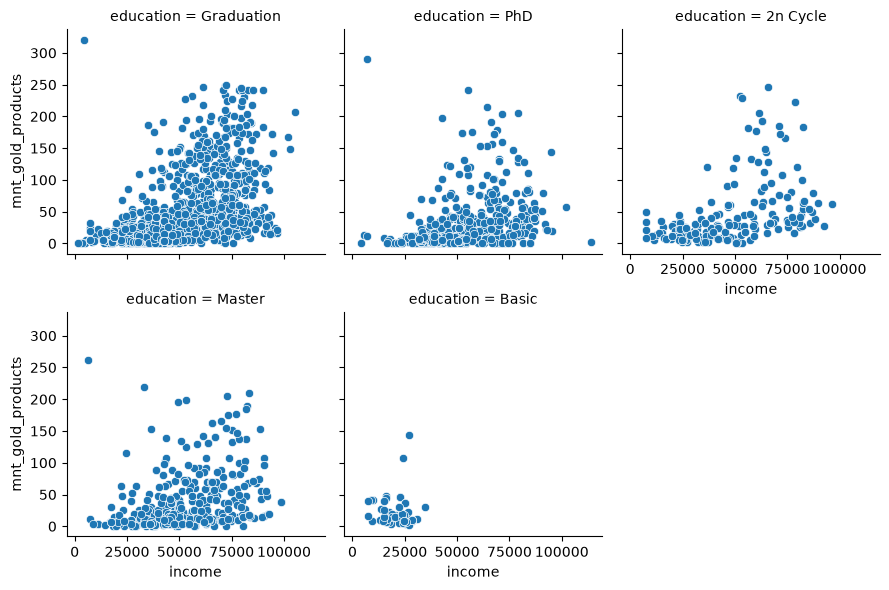

In [42]:
# dictionary used to contain dynamic variables
variable_names = {}
#amounts columns list
amounts_list = ["mnt_wines", "mnt_fruits", "mnt_meat_products", "mnt_fish_products", "mnt_sweet_products", "mnt_gold_products"]

for i in range(6):
    # defining the facet grid
    variable_names["g{0}".format(i)] = sns.FacetGrid(market_data, col="education", col_wrap=3)
    # mapping the facet grid with scatterplots of amounts product vs. income
    variable_names["g{0}".format(i)].map(sns.scatterplot, "income", amounts_list[i])
plt.show()

After observing the plots detailing the relationship between income, education, and purchasing behavior, the following can be seen:
* This store does not have many shoppers with a `Basic` education level.
* Regardless of the shopper's educational level, there is a positive, linear relationship for each `mnt_{type}_products`.
* `mnt_wines` has the strongest positive, linear relationship with `education` by `income`.

#### Purchasing Behavior by Age <a class="anchor" id="section3_5"></a>

The last main variable in our analysis plan is `age`. The `.scatterplot()` method is used to see if there is any relationship bewteen `age` and any purchasing behavior variables. The initial analysis showed no evidence of relationship as shown in all the graphs below. The graphs shown are:
* `total_purchases` vs. `age`
* `mnt_{type}_products` vs. `age`
* `num_{type}_purchases` vs. `age`

The process used to plot each one of these graphs is very similar to the one outlined in the Purchasing Behavior by income section.

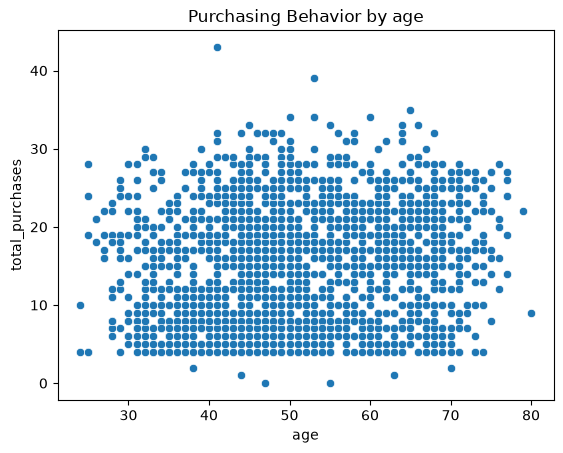

In [43]:
plt.figure()
# scatterplot of total purchases vs. age
sns.scatterplot(x=market_data["age"], y=market_data["total_purchases"])
plt.title("Purchasing Behavior by age")
plt.show()

It is hard to see any relationship between `age` and `total_purchases` in this plot.

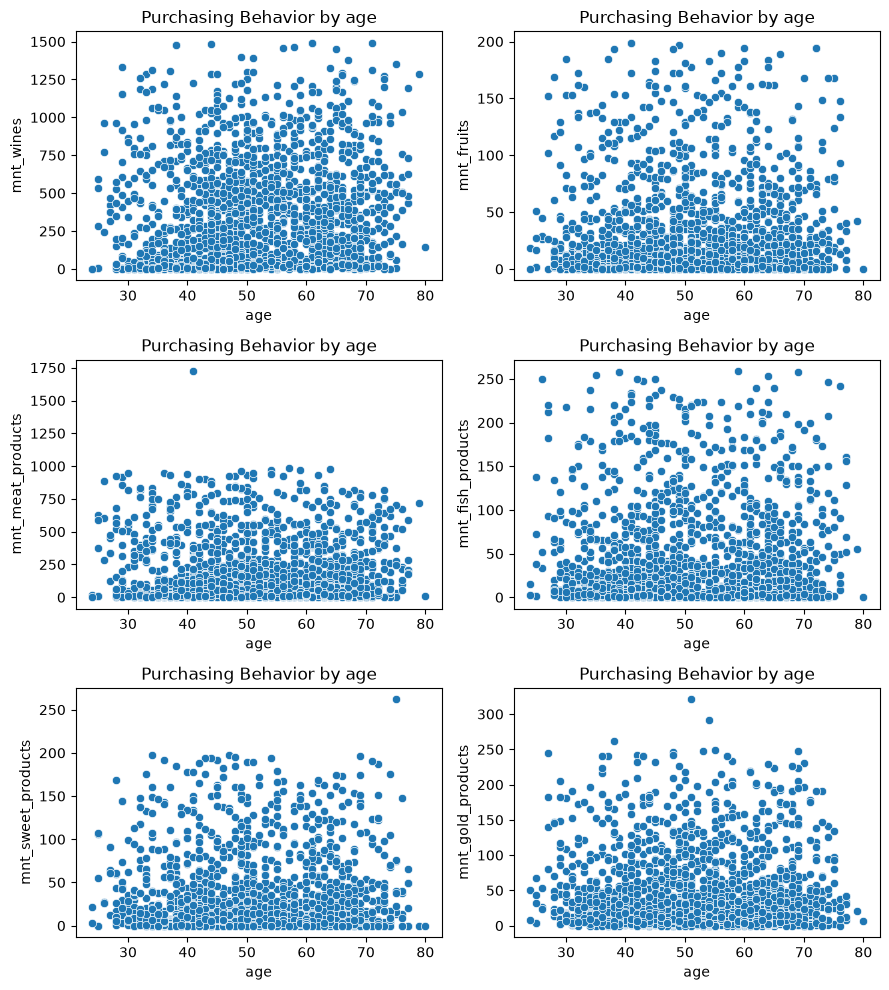

In [44]:
# amounts columns list
amounts_list = ["mnt_wines", "mnt_fruits", "mnt_meat_products", "mnt_fish_products", "mnt_sweet_products", "mnt_gold_products"]
plot = 0
fig = plt.figure(figsize=(9,10))
# looping through the length of the amounts columns list
for i in range(len(amounts_list)):
    plot += 1
    # setting up the subplots
    ax = plt.subplot(3, 2, plot)
    # plotting amounts purchased vs. income
    sns.scatterplot(y= market_data[amounts_list[i]], x=market_data["age"])
    plt.title("Purchasing Behavior by age")
plt.tight_layout()
plt.show()

Again, it is difficult to decipher any pattern between `age` and any `mnt_{type}_products` in any of these plots. A different strategy may be useful to analyze `age`.

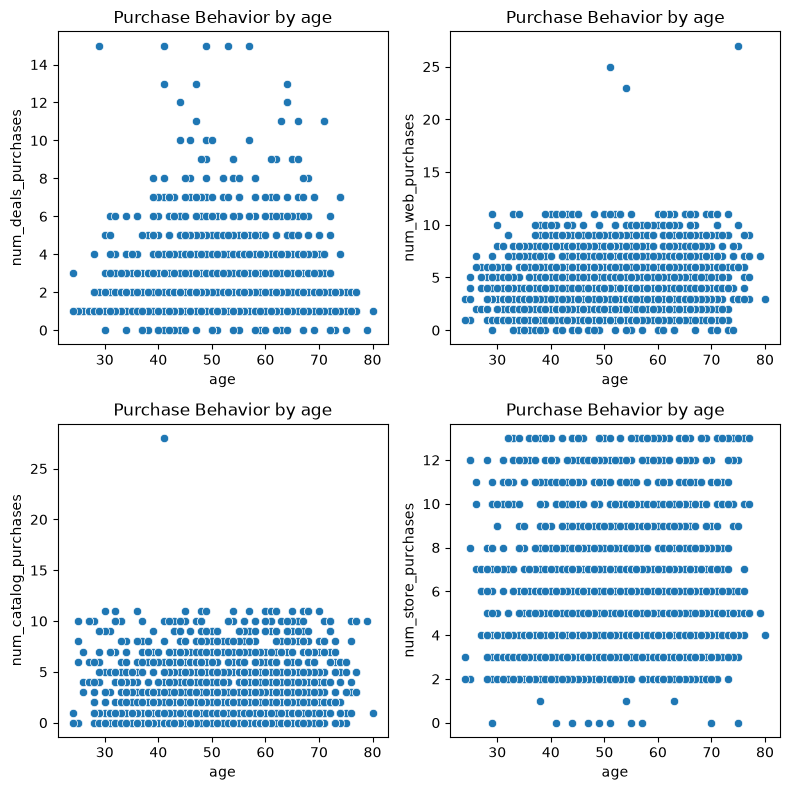

In [45]:
# num purchases columns list
num_purchases_cols = ["num_deals_purchases", "num_web_purchases", "num_catalog_purchases", "num_store_purchases"]
plot = 0
fig = plt.figure(figsize=(8,8))
# looping through the length of the list
for i in range(len(num_purchases_cols)):
    plot += 1
    # setting up the subplots
    ax = plt.subplot(2, 2, plot)
    # scatterplot of of num purchases vs. age
    sns.scatterplot(x=market_data["age"], y= market_data[num_purchases_cols[i]])
    plt.title("Purchase Behavior by age")

plt.tight_layout()
plt.show();

It is also difficult to decipher any pattern between `age` and any `num_{type}_purchases` in any of these plots. Because of this, a different analysis strategy will be used on the `age` variable.

To do further analysis on the `age` variable, A new column called `age_group` is added to `market_data`. It contains the following categories of ages:
* `18 to 35`
* `36 to 50`
* `51 to 70`
* `71 and Older`

This categorical variables may give a more clear story.

In [46]:
# function that breaks up each age into a group
def age_groups(age):
    if 18 <= age <= 35 : 
        return '18 to 35' 
    elif 35 < age <= 50 : 
        return '36 to 50'
    elif 50 < age <= 70 : 
        return '51 to 70'
    else : 
        return '71 and Older'

# applying the function to the dataframe
market_data['age_group'] = market_data['age'].apply(age_groups)
    

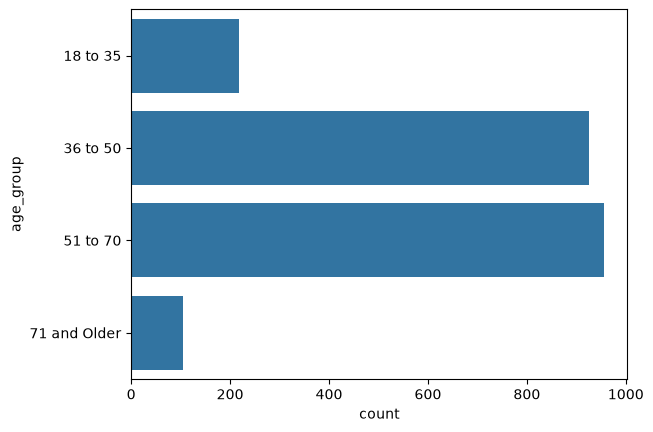

In [47]:
# plotting the age Group variable in a bar chart
plt.figure()
sns.countplot(market_data['age_group'], order=['18 to 35', '36 to 50', '51 to 70', '71 and Older'])
plt.show()

The `age_group` variable proved to be much more useful quickly as a bar chart showed that `36 to 50` and `51 to 70` year-old age groups dominated shopping at the store.

To take the analysis further, a new DataFrame is created, which only has information about shopper age (`age` and `age_group`) and the total purchase amounts each age group buys (`mnt_{type}_products`). This new DataFrame will have `age_groups` as row data to make plotting a grouped bar graph easier.

In [48]:
# new dataframe that is age and purchase amounts columns
age_plus_amounts = market_data.loc[:, ('age', 'mnt_wines', 'mnt_fruits', 'mnt_meat_products', 'mnt_fish_products', 
'mnt_sweet_products', 'mnt_gold_products')]
# breaking up the age bins
bins = [18, 35, 50, 70, 150]
# age group labels
labels = ['18 to 35', '36 to 50', '51 to 70', '71 and Older']

# adding age group to the new dataframe as rows
age_plus_amounts['age_group'] = pd.cut(age_plus_amounts.age, bins=bins, labels=labels)
age_plus_amounts = age_plus_amounts.groupby('age_group').sum().reset_index()


In [49]:
print(age_plus_amounts)

      age_group    age  mnt_wines  mnt_fruits  mnt_meat_products  \
0      18 to 35   6957      56038        6642              44974   
1      36 to 50  40808     237326       22532             132641   
2      51 to 70  57225     329022       25336             159619   
3  71 and Older   7676      52707        3709              27279   

   mnt_fish_products  mnt_sweet_products  mnt_gold_products  
0               8801                6648               9271  
1              32278               23723              37033  
2              36399               25433              45998  
3               5775                4014               4844  


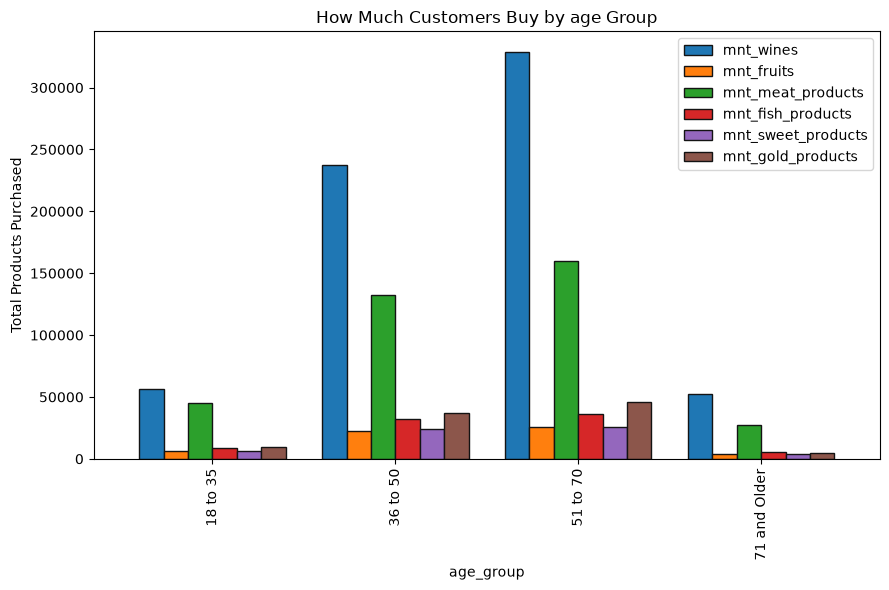

In [50]:
fig, ax = plt.subplots(figsize=(9, 6))

col_products = [
'mnt_wines', 
'mnt_fruits', 
'mnt_meat_products', 
'mnt_fish_products', 
'mnt_sweet_products', 
'mnt_gold_products'
]

# bar graph of amount of items bought in the store grouped by age group
age_plus_amounts.plot(x='age_group', y=col_products, kind='bar', ax=ax,  width=0.8, edgecolor='#131313')
plt.title("How Much Customers Buy by age Group")
plt.ylabel("Total Products Purchased")
plt.tight_layout()
plt.show()

Across the board, `age_group` does not seem to effect purchasing habits. Wine is the most popular bought item for each age group followed by meat products. The least popular bought item is fruits for each age group. The next analysis of interest is to see if `age_group` affects how many items customers buy each time. 

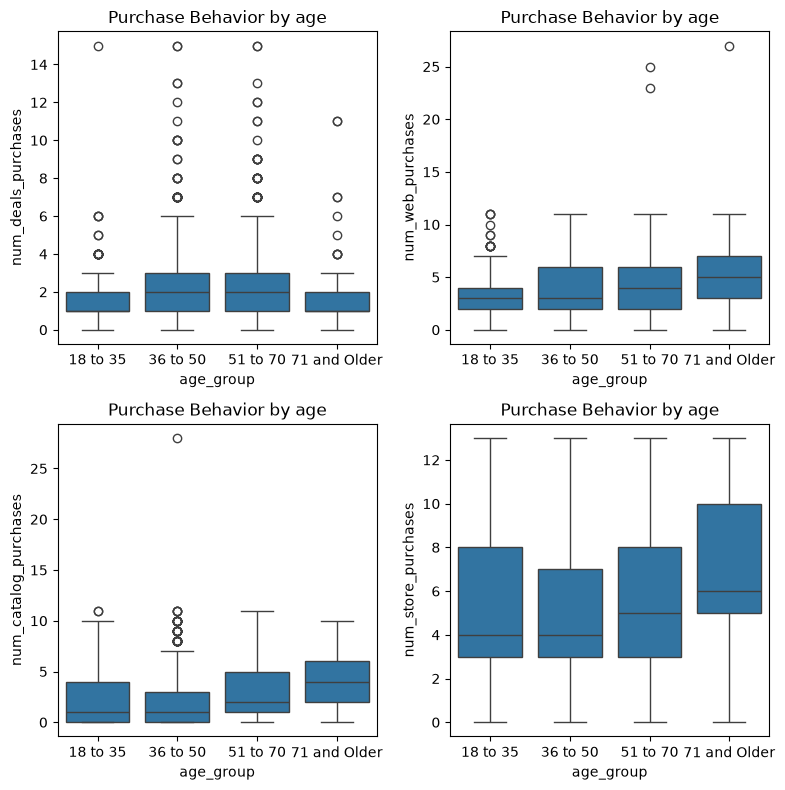

In [51]:
# num purchases columns list
num_purchases_cols = ["num_deals_purchases", "num_web_purchases", "num_catalog_purchases", "num_store_purchases"]
plot = 0
fig = plt.figure(figsize=(8,8))
# looping through the length of the list
for i in range(len(num_purchases_cols)):
    plot += 1
    # setting up the subplots
    ax = plt.subplot(2, 2, plot)
    # scatterplot of of num purchases vs. age
    sns.boxplot(x=market_data["age_group"], y= market_data[num_purchases_cols[i]], 
                order=["18 to 35", "36 to 50", "51 to 70", "71 and Older"])
    plt.title("Purchase Behavior by age")

plt.tight_layout()
plt.show()

This chart yields some very interesting insights. Here are some notable ones:
* `18 to 35` and `71 and Older` age groups tend to be the least interested in deals.
* On average, `71 and Older` age group customers tend to shop the most online, in store, and through the catalog.
* `36 to 50` and `51 to 70` age groups are interested in deals. Most likely this is because they receive more deals since they have more loyal customers.

This information could be super helpful for a marketing department as strategies could be used to increase `36 to 50` and `71 and Older` customers for the store.

### Conclusion 

#### Findings Overview

It has been shown `income` has the strongest relationship with purchase behavior of customers. However, interesting insights about `education` and `age` along with `age_group` have still been noted. These insights would be very helpful to how this store markets deals to their customers and prices items, such as wine since higher income groups tend to dominate alcohol sales. There is also opportunity to increase market to the `18 to 35` and `71 and Older` age groups to drive products sales. 